#### **Задание #3**

Выполнил: Мирасов Константин Владимирович

ИСУ: 466716

Группа: J3212

#### Импортируем библиотеки, объявляем необходимые константы и вспомогательные функции

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pathlib import Path

from sklearn.cluster import DBSCAN

In [57]:
PATH_TO_DATASET: Path = Path("../data/train_stations_europe.csv")
RADIUS_OF_EARTH: int = 6371

#### Загрузка и обработка датасета `train_stations_europe.csv`

In [58]:
train_stations_europe_dataframe = pd.read_csv(PATH_TO_DATASET, index_col="id", low_memory=False)
train_stations_europe_dataframe.head()

,name,name_norm,uic,latitude,longitude,parent_station_id,country,time_zone,is_city,is_main_station,is_airport,entur_id,entur_is_enabled,trenord_id,cercanias_id,cercanias_hub_id,cercanias_is_enabled
id,,,,,,,,,,,,,,,,,
1,Château-Arnoux – St-Auban,Chateau-Arnoux - St-Auban,NaN,44.081790,6.001625,NaN,FR,Europe/Paris,True,False,False,NaN,False,NaN,NaN,NaN,False
2,Château-Arnoux – St-Auban,Chateau-Arnoux - St-Auban,8775123.0,44.061565,5.997373,1.0,FR,Europe/Paris,False,True,False,NaN,False,NaN,NaN,NaN,False
3,Château-Arnoux Mairie,Chateau-Arnoux Mairie,8775122.0,44.063863,6.011248,1.0,FR,Europe/Paris,False,False,False,NaN,False,NaN,NaN,NaN,False
4,Digne-les-Bains,Digne-les-Bains,NaN,44.350000,6.350000,NaN,FR,Europe/Paris,True,False,False,NaN,False,NaN,NaN,NaN,False
6,Digne-les-Bains,Digne-les-Bains,8775149.0,44.088710,6.222982,4.0,FR,Europe/Paris,False,True,False,NaN,False,NaN,NaN,NaN,False


#### Визуализация станций поездов

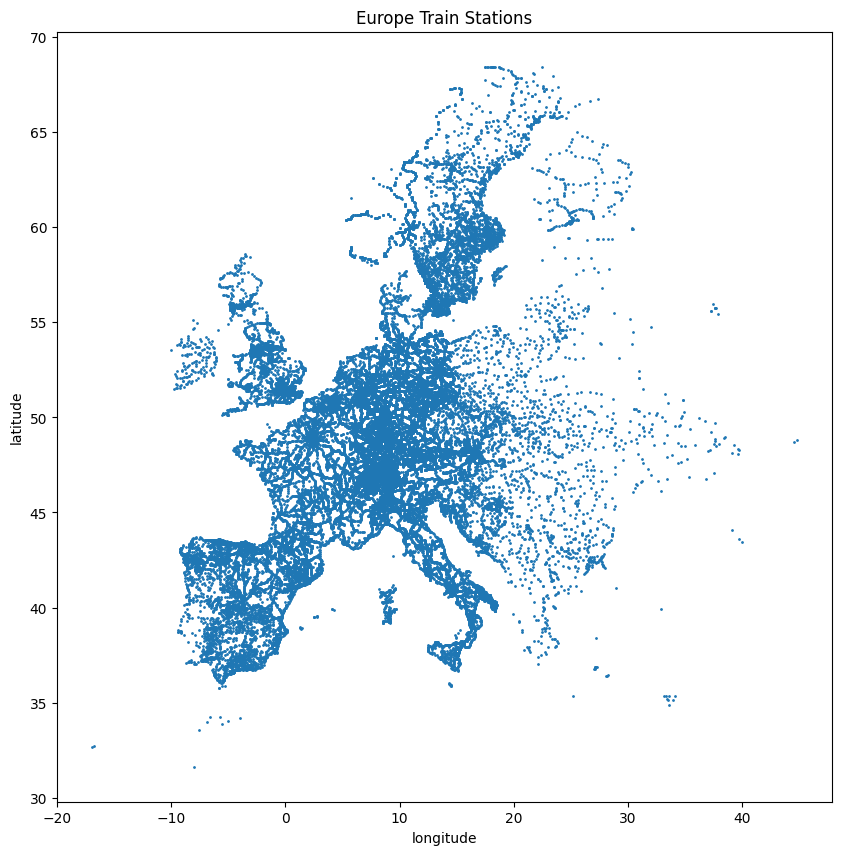

In [59]:
latitude = train_stations_europe_dataframe["latitude"]
longitude = train_stations_europe_dataframe["longitude"]

X = train_stations_europe_dataframe[["latitude", "longitude"]].dropna().to_numpy()
X_radians = np.radians(X)

plt.figure(figsize=(10, 10))

plt.scatter(longitude, latitude, s=1)

plt.title("Europe Train Stations")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

#### Применение метода кластеризации `DBSCAN`

In [60]:
eps_radians = 15 / RADIUS_OF_EARTH
min_stations = 10

dbscan = DBSCAN(eps=eps_radians, min_samples=min_stations, metric="haversine")
dbscan.fit(X_radians)

labels = dbscan.labels_

noise_count = np.count_nonzero(labels == -1)
print(f"Percentage of coverage: {(len(labels) - noise_count) / len(labels)}%")

n_clusters = len(set(labels)) - 1
print(f"Number of clusters: {n_clusters}")

Percentage of coverage: 0.897369455403025%
Number of clusters: 279


#### Визуализация кластеров после `DBSCAN`

In [61]:
new_cmap = plt.get_cmap("turbo", n_clusters)
colors = new_cmap(np.linspace(0, 1, n_clusters))
np.random.shuffle(colors)
random_cmap = mcolors.ListedColormap(colors)

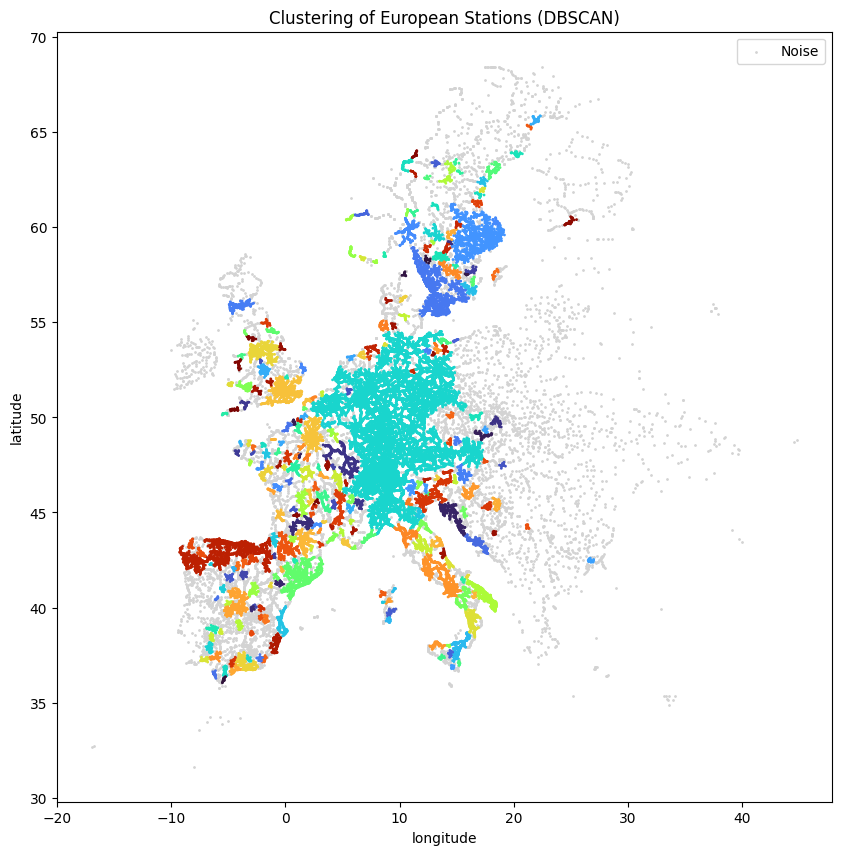

In [62]:
longitude = X[:, 1]
latitude = X[:, 0]

noise_mask = (labels == -1)
cluster_mask = (labels != -1)

plt.figure(figsize=(10, 10))

plt.scatter(longitude[noise_mask], latitude[noise_mask], c="lightgray", s=1, label="Noise")
plt.scatter(longitude[cluster_mask], latitude[cluster_mask], c=labels[cluster_mask], cmap=random_cmap, s=1)

plt.title("Clustering of European Stations (DBSCAN)")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.legend()
plt.show()

#### Статистика плотности кластеризации по странам

In [63]:
clean_dataframe = train_stations_europe_dataframe.dropna(subset=["longitude", "latitude"]).copy()
clean_dataframe["cluster_label"] = labels

stats = clean_dataframe.groupby("country").agg(
    total_stations=("cluster_label", "count"),
    noise_stations=("cluster_label", lambda x: (x == -1).sum())
)

stats["coverage_pct"] = (stats["total_stations"] - stats["noise_stations"]) / stats['total_stations'] * 100

In [ ]:
print("Top 10 countries by coverage percentage:\n")
print(stats.sort_values(by="coverage_pct", ascending=False).head(10))

Top 10 countries by coverage percentage:
         total_stations  noise_stations  coverage_pct
country                                              
AD                   10               0    100.000000
CH                22266               0    100.000000
LI                    2               0    100.000000
DE                13741             115     99.163089
LU                   66               1     98.484848
AT                 1542              41     97.341115
BE                  574              26     95.470383
IT                 4947             456     90.782292
SE                 5767             727     87.393792
GB                 2766             398     85.610991


In [ ]:
print("\nTop 10 countries with the most 'noisy' stations:\n")
print(stats.sort_values(by="noise_stations", ascending=False).head(10))


Top 10 countries with the most 'noisy' stations:
         total_stations  noise_stations  coverage_pct
country                                              
ES                 5189            1180     77.259588
FR                 6340             930     85.331230
SE                 5767             727     87.393792
PL                  531             489      7.909605
IT                 4947             456     90.782292
GB                 2766             398     85.610991
NO                  856             254     70.327103
CZ                  504             226     55.158730
UA                  215             215      0.000000
BG                  187             169      9.625668
